<a href="https://colab.research.google.com/github/mahjabeen28/Data-Analytics-using-python-project/blob/main/Final_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4) Food Delivery Sales and Customer Insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Order_ID": [101,102,103,104,105,106,107,108,109,110],
    "Time": ["12:30","01:00","07:15","08:00","12:45","07:30","09:00","01:15","08:30","07:45"],
    "Location": ["Chennai","Chennai","Coimbatore","Madurai","Chennai","Coimbatore","Madurai","Chennai","Madurai","Coimbatore"],
    "Item": ["Pizza","Burger","Pizza","Biriyani","Burger","Pizza","Biriyani","Pizza","Burger","Pizza"],
    "Quantity": [2,1,3,2,1,2,3,1,2,4],
    "Price": [150,50,150,200,50,150,200,150,50,150],
    "Total": [300,50,450,400,50,450,600,300,50,450],
    "Payment_Mode": ["UPI","Cash","Card","UPI","Cash","Card","UPI","UPI","Cash","Card"]
}

df = pd.DataFrame(data)

print(df)

   Order_ID   Time    Location      Item  Quantity  Price  Total Payment_Mode
0       101  12:30     Chennai     Pizza         2    150    300          UPI
1       102  01:00     Chennai    Burger         1     50     50         Cash
2       103  07:15  Coimbatore     Pizza         3    150    450         Card
3       104  08:00     Madurai  Biriyani         2    200    400          UPI
4       105  12:45     Chennai    Burger         1     50     50         Cash
5       106  07:30  Coimbatore     Pizza         2    150    450         Card
6       107  09:00     Madurai  Biriyani         3    200    600          UPI
7       108  01:15     Chennai     Pizza         1    150    300          UPI
8       109  08:30     Madurai    Burger         2     50     50         Cash
9       110  07:45  Coimbatore     Pizza         4    150    450         Card


In [2]:
df.head(10)

,Order_ID,Time,Location,Item,Quantity,Price,Total,Payment_Mode
0,101,12:30,Chennai,Pizza,2,150,300,UPI
1,102,01:00,Chennai,Burger,1,50,50,Cash
2,103,07:15,Coimbatore,Pizza,3,150,450,Card
3,104,08:00,Madurai,Biriyani,2,200,400,UPI
4,105,12:45,Chennai,Burger,1,50,50,Cash
5,106,07:30,Coimbatore,Pizza,2,150,450,Card
6,107,09:00,Madurai,Biriyani,3,200,600,UPI
7,108,01:15,Chennai,Pizza,1,150,300,UPI
8,109,08:30,Madurai,Burger,2,50,50,Cash
9,110,07:45,Coimbatore,Pizza,4,150,450,Card


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order_ID      10 non-null     int64 
 1   Time          10 non-null     object
 2   Location      10 non-null     object
 3   Item          10 non-null     object
 4   Quantity      10 non-null     int64 
 5   Price         10 non-null     int64 
 6   Total         10 non-null     int64 
 7   Payment_Mode  10 non-null     object
dtypes: int64(4), object(4)
memory usage: 772.0+ bytes
None


In [4]:
print(df.shape)

(10, 8)


In [5]:
print(df.isnull().sum())

Order_ID        0
Time            0
Location        0
Item            0
Quantity        0
Price           0
Total           0
Payment_Mode    0
dtype: int64


Analyze Time,Location,Item

In [6]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

print(df["Hour"].value_counts())

print(df["Location"].value_counts())

print(df["Item"].value_counts())

Hour
7     3
12    2
1     2
8     2
9     1
Name: count, dtype: int64
Location
Chennai       4
Coimbatore    3
Madurai       3
Name: count, dtype: int64
Item
Pizza       5
Burger      3
Biriyani    2
Name: count, dtype: int64


/tmp/ipykernel_4595/2872125817.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


Filtering

In [7]:
chennai_orders = df[df["Location"] == "Chennai"]

print(chennai_orders)

   Order_ID   Time Location    Item  Quantity  Price  Total Payment_Mode  Hour
0       101  12:30  Chennai   Pizza         2    150    300          UPI    12
1       102  01:00  Chennai  Burger         1     50     50         Cash     1
4       105  12:45  Chennai  Burger         1     50     50         Cash    12
7       108  01:15  Chennai   Pizza         1    150    300          UPI     1


Groupby Analysis

In [8]:
location_orders = df.groupby("Location")["Total"].sum()

print(location_orders)

Location
Chennai        700
Coimbatore    1350
Madurai       1050
Name: Total, dtype: int64


Peak Order Time

In [9]:
peak_orders = df.groupby("Hour").size()

print(peak_orders)

print("peak Hour =", peak_orders.idxmax())

Hour
1     2
7     3
8     2
9     1
12    2
dtype: int64
peak Hour = 7


Most Popular Dishes

In [10]:
popular_items = df["Item"].value_counts()

print(popular_items)

print("Most Popular Dish =", popular_items.idxmax())

Item
Pizza       5
Burger      3
Biriyani    2
Name: count, dtype: int64
Most Popular Dish = Pizza


Dashboard Line,Bar,Pie Charts

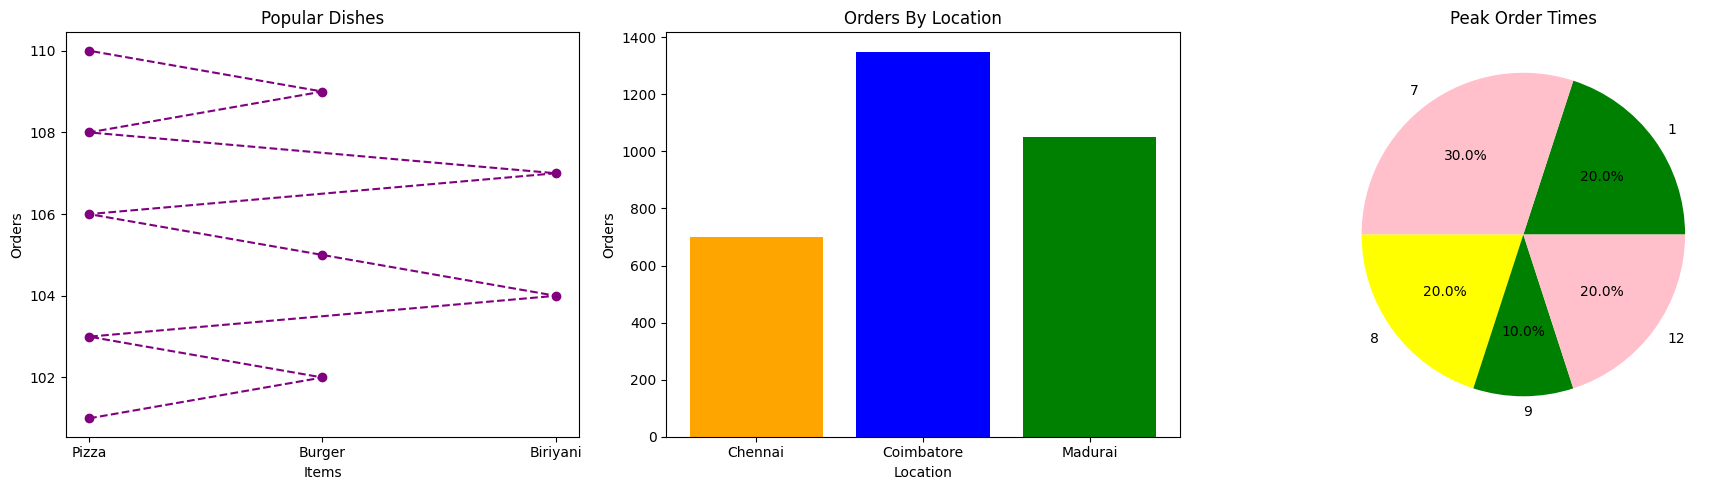

In [11]:
plt.figure(figsize=(18,5))

#Line Chart
plt.subplot(1,3,1)

plt.plot(df['Item'],df['Order_ID'],
         color = "Purple",
         marker = "o",
         linestyle = "--")

plt.title("Popular Dishes")

plt.xlabel("Items")

plt.ylabel("Orders")

#Bar Chart
plt.subplot(1,3,2)

plt.bar(location_orders.index, location_orders.values,
         color = ("orange","Blue","Green"))

plt.title("Orders By Location")

plt.xlabel("Location")

plt.ylabel("Orders")

#Pie Chart
plt.subplot(1,3,3)

hours = peak_orders.index

orders = peak_orders.values

plt.pie(orders,
        labels = hours,
        autopct = "%1.1f%%", colors = ["green","Pink","Yellow"])

plt.title("Peak Order Times")

plt.tight_layout()

plt.show()

Final Business Insights

In [12]:
print("Most Popular Dish:",popular_items.idxmax())

print("Peak Order Hour:",peak_orders.idxmax())

print("Top Location:",df["Location"].value_counts().idxmax())

Most Popular Dish: Pizza
Peak Order Hour: 7
Top Location: Chennai
